In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/DataCoSupplyChainDataset.csv", encoding='latin1')
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/15/2018 11:24,Standard Class


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41653 entries, 0 to 41652
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Type                           41653 non-null  object 
 1   Days for shipping (real)       41653 non-null  int64  
 2   Days for shipment (scheduled)  41653 non-null  int64  
 3   Benefit per order              41653 non-null  float64
 4   Sales per customer             41653 non-null  float64
 5   Delivery Status                41653 non-null  object 
 6   Late_delivery_risk             41653 non-null  int64  
 7   Category Id                    41653 non-null  int64  
 8   Category Name                  41653 non-null  object 
 9   Customer City                  41653 non-null  object 
 10  Customer Country               41653 non-null  object 
 11  Customer Email                 41653 non-null  object 
 12  Customer Fname                 41653 non-null 

In [4]:
df.isnull().sum()

,0
Type,0
Days for shipping (real),0
Days for shipment (scheduled),0
Benefit per order,0
Sales per customer,0
Delivery Status,0
Late_delivery_risk,0
Category Id,0
Category Name,0
Customer City,0


In [5]:
df["Product Description"]

,Product Description
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
41648,NaN
41649,NaN
41650,NaN
41651,NaN


In [6]:
df.drop(columns=["Product Description"], inplace=True)

In [7]:
df.drop(columns=["Order Zipcode"], inplace=True)

In [8]:
# df.drop(columns=["Order Zipcode"], inplace=True)

In [9]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Product Card Id', 'Product Category Id', 'Product Image',
       'Product Na

In [10]:
drop_columns = ["Customer Password","Customer Street","Order Item Cardprod Id","Product Image","Customer Fname","Customer Lname","Customer Email"]

In [11]:
for i in drop_columns:
  df.drop(columns=[i], inplace=True)

In [12]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Id', 'Customer Segment', 'Customer State',
       'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude',
       'Longitude', 'Market', 'Order City', 'Order Country',
       'Order Customer Id', 'order date (DateOrders)', 'Order Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Product Card Id', 'Product Category Id', 'Product Name',
       'Product Price', 'Product Status', 'shipping date (DateOrders)',
       'Shipping Mode'],
      dtype='object')

In [13]:
(df["Category Id"] == df["Product Category Id"]).all()

np.False_

In [14]:
df.dropna(inplace = True )
df.isnull().sum()

,0
Type,0
Days for shipping (real),0
Days for shipment (scheduled),0
Benefit per order,0
Sales per customer,0
Delivery Status,0
Late_delivery_risk,0
Category Id,0
Category Name,0
Customer City,0


In [15]:
df.size

1832644

In [16]:
dfc = df.copy()

In [17]:
df["Delayed"] = df["Days for shipping (real)"] - df["Days for shipment (scheduled)"]
df["Delayed"].value_counts()

,count
Delayed,
1,14368
0,7584
2,6592
-2,4894
-1,4769
4,1765
3,1679


In [18]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order State,Order Status,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,Delayed
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Java Occidental,COMPLETE,1360.0,73.0,Smart watch,327.75,0.0,2/3/2018 22:56,Standard Class,-1
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,Rajastán,PENDING,1360.0,73.0,Smart watch,327.75,0.0,1/18/2018 12:27,Standard Class,1
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,Rajastán,CLOSED,1360.0,73.0,Smart watch,327.75,0.0,1/17/2018 12:06,Standard Class,0
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Queensland,COMPLETE,1360.0,73.0,Smart watch,327.75,0.0,1/16/2018 11:45,Standard Class,-1
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Queensland,PENDING_PAYMENT,1360.0,73.0,Smart watch,327.75,0.0,1/15/2018 11:24,Standard Class,-2


In [19]:
def category(val):
  if val < 0:
    return "Ahead of arrival"
  elif val == 0:
    return "On Time"
  elif val > 2: # Check for Major Delay FIRST
    return "Major Delay"
  else: # This covers values 1 and 2
    return "Minor Delay"

In [20]:
df["Delay_Category"] = df["Delayed"].apply(category)
df["Delay_Category"].value_counts()

,count
Delay_Category,
Minor Delay,20960
Ahead of arrival,9663
On Time,7584
Major Delay,3444


In [21]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Status,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,Delayed,Delay_Category
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,COMPLETE,1360.0,73.0,Smart watch,327.75,0.0,2/3/2018 22:56,Standard Class,-1,Ahead of arrival
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,PENDING,1360.0,73.0,Smart watch,327.75,0.0,1/18/2018 12:27,Standard Class,1,Minor Delay
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,CLOSED,1360.0,73.0,Smart watch,327.75,0.0,1/17/2018 12:06,Standard Class,0,On Time
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,COMPLETE,1360.0,73.0,Smart watch,327.75,0.0,1/16/2018 11:45,Standard Class,-1,Ahead of arrival
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,PENDING_PAYMENT,1360.0,73.0,Smart watch,327.75,0.0,1/15/2018 11:24,Standard Class,-2,Ahead of arrival


In [22]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Id', 'Customer Segment', 'Customer State',
       'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude',
       'Longitude', 'Market', 'Order City', 'Order Country',
       'Order Customer Id', 'order date (DateOrders)', 'Order Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Product Card Id', 'Product Category Id', 'Product Name',
       'Product Price', 'Product Status', 'shipping date (DateOrders)',
       'Shipping Mode', 'Delayed', 'Delay_Category'],
      dtype='object')

In [23]:
df["Profit_Margin"] = (df["Order Profit Per Order"] / df["Sales"])  * 100

df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,Delayed,Delay_Category,Profit_Margin
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,1360.0,73.0,Smart watch,327.75,0.0,2/3/2018 22:56,Standard Class,-1,Ahead of arrival,27.841342
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,1360.0,73.0,Smart watch,327.75,0.0,1/18/2018 12:27,Standard Class,1,Minor Delay,-75.999999
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,1360.0,73.0,Smart watch,327.75,0.0,1/17/2018 12:06,Standard Class,0,On Time,-75.600305
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,1360.0,73.0,Smart watch,327.75,0.0,1/16/2018 11:45,Standard Class,-1,Ahead of arrival,6.974829
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,1360.0,73.0,Smart watch,327.75,0.0,1/15/2018 11:24,Standard Class,-2,Ahead of arrival,40.948896


In [24]:
df["Profit_Margin"].mean()

np.float64(10.954568222091266)

In [25]:
# Checking Outliear
df["Profit_Margin"].describe()

,Profit_Margin
count,41651.000000
mean,10.954568
std,41.997349
min,-274.999998
25%,6.237706
50%,24.248018
75%,33.599152
max,50.022738


In [26]:
df[df["Profit_Margin"] < 0]

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,Delayed,Delay_Category,Profit_Margin
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,1360.0,73.0,Smart watch,327.750000,0.0,1/18/2018 12:27,Standard Class,1,Minor Delay,-75.999999
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,1360.0,73.0,Smart watch,327.750000,0.0,1/17/2018 12:06,Standard Class,0,On Time,-75.600305
15,DEBIT,2,1,-259.579987,324.470001,Late delivery,1,73,Sporting Goods,Caguas,...,1360.0,73.0,Smart watch,327.750000,0.0,1/15/2018 7:33,First Class,1,Minor Delay,-79.200606
16,PAYMENT,5,2,-246.360001,321.200012,Late delivery,1,73,Sporting Goods,Canovanas,...,1360.0,73.0,Smart watch,327.750000,0.0,1/18/2018 7:12,Second Class,3,Major Delay,-75.167048
28,DEBIT,3,4,-17.139999,272.029999,Advance shipping,0,73,Sporting Goods,Roseville,...,1360.0,73.0,Smart watch,327.750000,0.0,1/16/2018 3:00,Standard Class,-1,Ahead of arrival,-5.229596
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41633,DEBIT,6,4,-456.720001,260.980011,Late delivery,1,43,Camping & Hiking,Caguas,...,957.0,43.0,Diamondback Women's Serene Classic Comfort Bi,299.980011,0.0,12/2/2015 14:25,Standard Class,2,Minor Delay,-152.250145
41637,DEBIT,5,4,-509.970001,339.980011,Late delivery,1,45,Fishing,Caguas,...,1004.0,45.0,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0.0,11/26/2015 0:56,Standard Class,1,Minor Delay,-127.498872
41638,DEBIT,5,4,-395.220001,254.979996,Late delivery,1,43,Camping & Hiking,Caguas,...,957.0,43.0,Diamondback Women's Serene Classic Comfort Bi,299.980011,0.0,2/23/2016 0:17,Standard Class,1,Minor Delay,-131.748779
41642,DEBIT,5,4,-176.389999,251.979996,Late delivery,1,43,Camping & Hiking,Caguas,...,957.0,43.0,Diamondback Women's Serene Classic Comfort Bi,299.980011,0.0,3/31/2016 21:26,Standard Class,1,Minor Delay,-58.800584


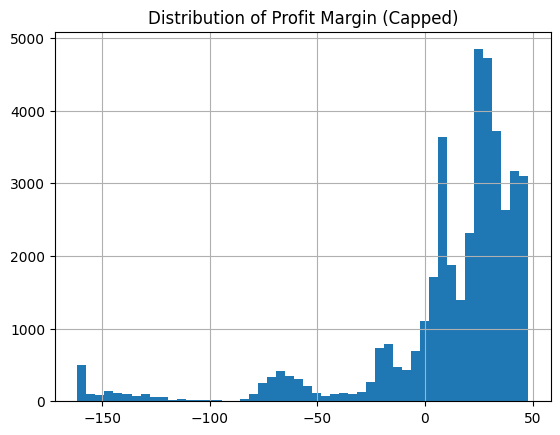

In [27]:
import numpy as np

# Define your caps at the 1st and 99th percentile
lower_cap = df['Profit_Margin'].quantile(0.01)
upper_cap = df['Profit_Margin'].quantile(0.99)

# Apply the capping
df['Profit_Margin_Capped'] = df['Profit_Margin'].clip(lower=lower_cap, upper=upper_cap)

# Now, visualize the distribution to see the improvement
import matplotlib.pyplot as plt
df['Profit_Margin_Capped'].hist(bins=50)
plt.title("Distribution of Profit Margin (Capped)")
plt.show()

In [28]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Id', 'Customer Segment', 'Customer State',
       'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude',
       'Longitude', 'Market', 'Order City', 'Order Country',
       'Order Customer Id', 'order date (DateOrders)', 'Order Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Product Card Id', 'Product Category Id', 'Product Name',
       'Product Price', 'Product Status', 'shipping date (DateOrders)',
       'Shipping Mode', 'Delayed', 'Delay_Category', 'Profit_Margin',
       'Pro

In [29]:
df["order date (DateOrders)"] = pd.to_datetime(df["order date (DateOrders)"])
df["shipping date (DateOrders)"] = pd.to_datetime(df["shipping date (DateOrders)"])
df["Order_processing_Time"] = (df["shipping date (DateOrders)"] - df["order date (DateOrders)"]).dt.days




In [30]:
df["Cost"] = df["Sales"] - df["Order Profit Per Order"]
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,Delayed,Delay_Category,Profit_Margin,Profit_Margin_Capped,Order_processing_Time,Cost
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,327.75,0.0,2018-02-03 22:56:00,Standard Class,-1,Ahead of arrival,27.841342,27.841342,3,236.500000
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,327.75,0.0,2018-01-18 12:27:00,Standard Class,1,Minor Delay,-75.999999,-75.999999,5,576.839996
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,327.75,0.0,2018-01-17 12:06:00,Standard Class,0,On Time,-75.600305,-75.600305,4,575.529999
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,327.75,0.0,2018-01-16 11:45:00,Standard Class,-1,Ahead of arrival,6.974829,6.974829,3,304.889999
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,327.75,0.0,2018-01-15 11:24:00,Standard Class,-2,Ahead of arrival,40.948896,40.948896,2,193.539993


In [31]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Id', 'Customer Segment', 'Customer State',
       'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude',
       'Longitude', 'Market', 'Order City', 'Order Country',
       'Order Customer Id', 'order date (DateOrders)', 'Order Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Product Card Id', 'Product Category Id', 'Product Name',
       'Product Price', 'Product Status', 'shipping date (DateOrders)',
       'Shipping Mode', 'Delayed', 'Delay_Category', 'Profit_Margin',
       'Pro

In [32]:
df["order date (DateOrders)"] = pd.to_datetime(df["order date (DateOrders)"])
df["shipping date (DateOrders)"] = pd.to_datetime(df["shipping date (DateOrders)"])

In [33]:

cols_to_clean = ['Sales', 'Profit_Margin', 'Cost', 'Order_processing_Time','Benefit per order']

for col in cols_to_clean:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1


    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR


    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print(f"Dataset size after cleaning: {df.shape}")

Dataset size after cleaning: (35911, 50)


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35911 entries, 0 to 41651
Data columns (total 50 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Type                           35911 non-null  object        
 1   Days for shipping (real)       35911 non-null  int64         
 2   Days for shipment (scheduled)  35911 non-null  int64         
 3   Benefit per order              35911 non-null  float64       
 4   Sales per customer             35911 non-null  float64       
 5   Delivery Status                35911 non-null  object        
 6   Late_delivery_risk             35911 non-null  int64         
 7   Category Id                    35911 non-null  int64         
 8   Category Name                  35911 non-null  object        
 9   Customer City                  35911 non-null  object        
 10  Customer Country               35911 non-null  object        
 11  Customer Id         

In [35]:
df['order_date'] = pd.to_datetime(df['order date (DateOrders)'])
df['Is_Weekend_Order'] = (df['order_date'].dt.weekday >= 5).astype(int)
df['Order_Type'] = np.where(df['Is_Weekend_Order'] == 1, 'Weekend', 'Weekday')

In [36]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Shipping Mode,Delayed,Delay_Category,Profit_Margin,Profit_Margin_Capped,Order_processing_Time,Cost,order_date,Is_Weekend_Order,Order_Type
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Standard Class,-1,Ahead of arrival,27.841342,27.841342,3,236.500000,2018-01-31 22:56:00,0,Weekday
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Standard Class,-1,Ahead of arrival,6.974829,6.974829,3,304.889999,2018-01-13 11:45:00,1,Weekend
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Standard Class,-2,Ahead of arrival,40.948896,40.948896,2,193.539993,2018-01-13 11:24:00,1,Weekend
5,TRANSFER,6,4,18.580000,294.980011,Shipping canceled,0,73,Sporting Goods,Tonawanda,...,Standard Class,2,Minor Delay,5.668955,5.668955,6,309.170000,2018-01-13 11:03:00,1,Weekend
6,DEBIT,2,1,95.180000,288.420013,Late delivery,1,73,Sporting Goods,Caguas,...,First Class,1,Minor Delay,29.040427,29.040427,2,232.570000,2018-01-13 10:42:00,1,Weekend


In [37]:
import pandas as pd
import numpy as np


df['order_date'] = pd.to_datetime(df['order date (DateOrders)'])

margin_bins = [-float('inf'), 10, 30, float('inf')]
margin_labels = ['Low Margin', 'Medium Margin', 'High Margin']
df['Margin_Tier'] = pd.cut(df['Profit_Margin_Capped'], bins=margin_bins, labels=margin_labels)

df['Peak_Season_Flag'] = df['order_date'].dt.month.isin([10, 11, 12]).astype(int)

customer_delay_rates = df.groupby('Customer Id')['Late_delivery_risk'].transform('mean')

conditions = [
    (customer_delay_rates <= 0.30),
    (customer_delay_rates > 0.30) & (customer_delay_rates <= 0.60),
    (customer_delay_rates > 0.60)
]
reliability_labels = ['High Reliability Customer', 'Medium Reliability Customer', 'Low Reliability Customer']
df['Customer_Reliability'] = np.select(conditions, reliability_labels, default='Medium Reliability Customer')

In [38]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Profit_Margin,Profit_Margin_Capped,Order_processing_Time,Cost,order_date,Is_Weekend_Order,Order_Type,Margin_Tier,Peak_Season_Flag,Customer_Reliability
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,27.841342,27.841342,3,236.500000,2018-01-31 22:56:00,0,Weekday,Medium Margin,0,High Reliability Customer
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,6.974829,6.974829,3,304.889999,2018-01-13 11:45:00,1,Weekend,Low Margin,0,High Reliability Customer
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,40.948896,40.948896,2,193.539993,2018-01-13 11:24:00,1,Weekend,High Margin,0,High Reliability Customer
5,TRANSFER,6,4,18.580000,294.980011,Shipping canceled,0,73,Sporting Goods,Tonawanda,...,5.668955,5.668955,6,309.170000,2018-01-13 11:03:00,1,Weekend,Low Margin,0,High Reliability Customer
6,DEBIT,2,1,95.180000,288.420013,Late delivery,1,73,Sporting Goods,Caguas,...,29.040427,29.040427,2,232.570000,2018-01-13 10:42:00,1,Weekend,Medium Margin,0,Low Reliability Customer


In [39]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Id', 'Customer Segment', 'Customer State',
       'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude',
       'Longitude', 'Market', 'Order City', 'Order Country',
       'Order Customer Id', 'order date (DateOrders)', 'Order Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Product Card Id', 'Product Category Id', 'Product Name',
       'Product Price', 'Product Status', 'shipping date (DateOrders)',
       'Shipping Mode', 'Delayed', 'Delay_Category', 'Profit_Margin',
       'Pro

In [40]:
df.to_csv("DataCo_SupplyChain_Cleaned_Final.csv", index=False)